# 3 A portfolio with a risky and a safe asset

In [8]:
# Imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 3.1 Question 1

#### 3.1.1 Simulation of returns

Using `np.random.default_rng(2026)`, the shocks $\varepsilon_t$ were drawn in one array with shape $(N,T)=(50{,}000,40)$. The risky gross returns were then calculated as

$$R_t=\exp(\mu+\sigma\varepsilon_t).$$

#### 3.1.2 Moments of the return distribution

The simulated moments are:

| Quantity | Simulated | Theoretical |
|---|---:|---:|
| Mean of $\log(R_t)$ | 0.050023 | $\mu=0.050000$ |
| Standard deviation of $\log(R_t)$ | 0.199965 | $\sigma=0.200000$ |
| Mean of $R_t$ | 1.072527 | $\exp(\mu+\frac12\sigma^2)=1.072508$ |

The simulated values are very close to the theoretical values. The small differences are sampling variation from the finite number of draws.

#### 3.1.3 Figure

The first panel shows the distribution of the risky gross return. The second panel shows the value of $1$ invested in the risky asset for 20 portfolios and in the safe asset. The risky paths vary substantially because of the shocks, while the safe-asset path is deterministic. The logarithmic y-axis makes relative growth easier to compare.


Mean log(R): 0.050023 (theoretical mu = 0.050000)
Std. log(R): 0.199965 (theoretical sigma = 0.200000)
Mean R: 1.072527 (theoretical value = 1.072508)


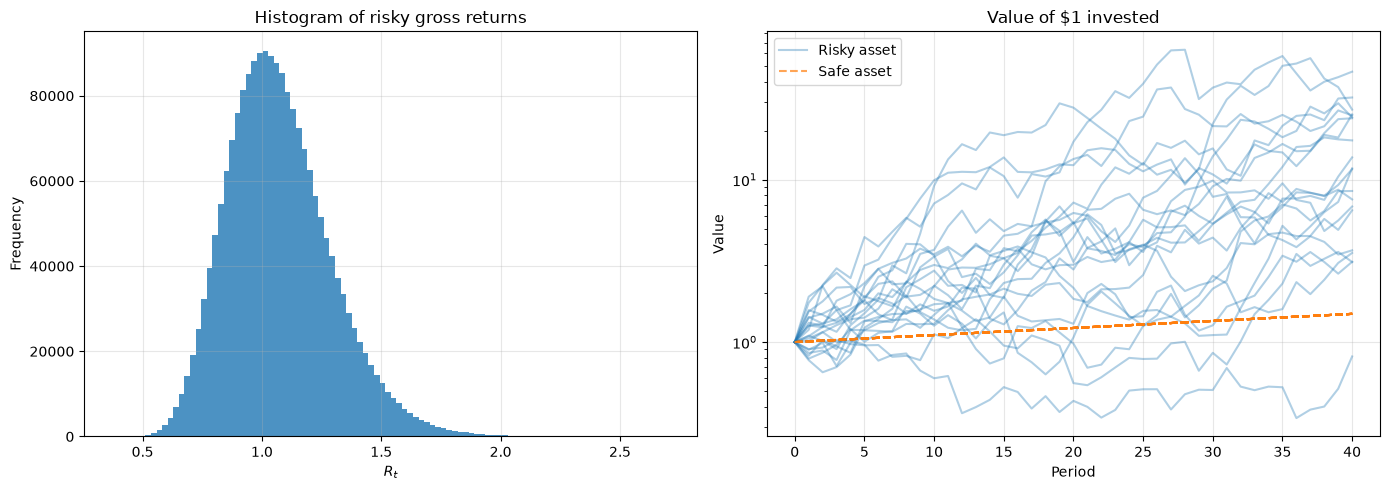

In [9]:
from PortfolioModel import PortfolioModelClass

# Calibration
par = PortfolioModelClass().par
mu, sigma, r = par.mu, par.sigma, par.r
R_safe = np.exp(r)
T, N = par.T, par.N

# Draw the same risky returns for every experiment
rng = np.random.default_rng(par.seed)
eps = rng.normal(size=(N, T))
R_risky = np.exp(mu + sigma * eps)

# Moments of log returns and gross returns
mean_logR = np.log(R_risky).mean()
std_logR = np.log(R_risky).std()
mean_R = R_risky.mean()
theoretical_mean_R = np.exp(mu + 0.5 * sigma**2)

print(f'Mean log(R): {mean_logR:.6f} (theoretical mu = {mu:.6f})')
print(f'Std. log(R): {std_logR:.6f} (theoretical sigma = {sigma:.6f})')
print(f'Mean R: {mean_R:.6f} (theoretical value = {theoretical_mean_R:.6f})')

# Figure 1: return distribution and value of $1 invested
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(R_risky.ravel(), bins=100, color='tab:blue', alpha=0.8)
ax[0].set(title='Histogram of risky gross returns', xlabel='$R_t$', ylabel='Frequency')
ax[0].grid(alpha=0.3)

time = np.arange(T + 1)
for portfolio in range(20):
    risky_path = np.r_[1, np.cumprod(R_risky[portfolio])]
    safe_path = R_safe ** time
    ax[1].plot(time, risky_path, color='tab:blue', alpha=0.35,
               label='Risky asset' if portfolio == 0 else None)
    ax[1].plot(time, safe_path, '--', color='tab:orange', alpha=0.7,
               label='Safe asset' if portfolio == 0 else None)
ax[1].set(yscale='log', title='Value of $1 invested', xlabel='Period', ylabel='Value')
ax[1].legend()
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Question 2

#### 3.2.1 Portfolio simulator

The simulator loops over the $T=40$ periods and vectorizes over the $N=50{,}000$ portfolios. It stores $W_t$ and $\theta_t$ for $t=0,\ldots,T$. Before each return is realized, the portfolio is rebalanced when $|\theta_t-\theta^*|>\Delta$. The two rules below use exactly the same simulated risky returns.

#### 3.2.2 Extreme trading rules

With transaction costs set to $\tau=0$, the six requested statistics are:

| Rule | Average trades | Average distance | Mean $W_T$ | Median $W_T$ | 10th percentile $W_T$ | Expected utility |
|---|---:|---:|---:|---:|---:|---:|
| $\Delta=0$ | 39.000000 | 0.039395 | 5.043602 | 4.081492 | 1.793667 | -0.067829 |
| $\Delta=1$ | 0.000000 | 0.191138 | 8.975620 | 4.447803 | 1.485479 | -0.076690 |

The $\Delta=0$ rule trades after the initial period whenever the share has moved, so the average number of trades is 39 rather than 40. With $\Delta=1$, no portfolio is traded because the risky share always remains in $[0,1]$.

#### 3.2.3 Figure and description

With continuous rebalancing, the mean risky share stays at the target $\theta^*=0.5$ and the percentile band is relatively narrow. When the portfolio is never traded, the risky share changes after every return shock because the risky and safe assets have different returns. Its dispersion widens over time, and the mean drifts above the target in this simulation. The never-traded rule has higher mean terminal wealth, but lower expected utility because it exposes the investor to more risk.


           Avg trades  Avg distance   Mean WT  Median WT    P10 WT  \
Delta = 0        39.0      0.039395  5.043602   4.081492  1.793667   
Delta = 1         0.0      0.191138  8.975620   4.447803  1.485479   

           Expected utility  
Delta = 0         -0.067829  
Delta = 1         -0.076690  


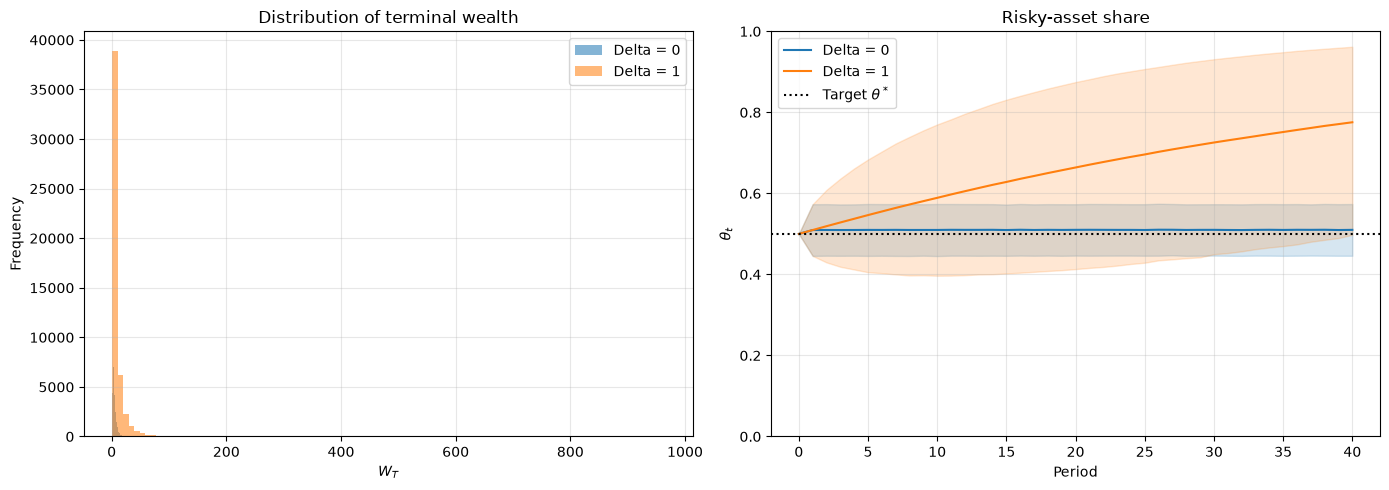

In [10]:
# 3.2 Simulate the two extreme rules using the same returns
trade_model = PortfolioModelClass(Delta=0, tau=0)
never_model = PortfolioModelClass(Delta=1, tau=0)

trade_model.simulate(R_risky)
never_model.simulate(R_risky)

stats_trade = trade_model.summary()
stats_never = never_model.summary()
comparison = pd.DataFrame([stats_trade, stats_never], index=['Delta = 0', 'Delta = 1'])
print(comparison.round(6))

# Figure 2: terminal wealth and the evolution of risky shares
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(trade_model.sim.W[:, -1], bins=100, alpha=0.55, label='Delta = 0')
ax[0].hist(never_model.sim.W[:, -1], bins=100, alpha=0.55, label='Delta = 1')
ax[0].set(title='Distribution of terminal wealth', xlabel='$W_T$', ylabel='Frequency')
ax[0].legend()
ax[0].grid(alpha=0.3)

for model, label, color in [(trade_model, 'Delta = 0', 'tab:blue'),
                             (never_model, 'Delta = 1', 'tab:orange')]:
    theta = model.sim.theta
    mean_theta = theta.mean(axis=0)
    p10, p90 = np.percentile(theta, [10, 90], axis=0)
    ax[1].plot(time, mean_theta, color=color, label=label)
    ax[1].fill_between(time, p10, p90, color=color, alpha=0.18)
ax[1].axhline(trade_model.par.theta_star, color='black', linestyle=':', label=r'Target $\theta^*$')
ax[1].set(title='Risky-asset share', xlabel='Period', ylabel=r'$\theta_t$', ylim=(0, 1))
ax[1].legend()
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.3 Question 3

#### 3.3.1 Results for different no-trade bands

The six requested statistics are reported below. Average distance is measured before trading and averaged over all portfolios and periods.

| $\Delta$ | Average trades | Average distance | Mean $W_T$ | Median $W_T$ | 10th percentile $W_T$ | Expected utility |
|---:|---:|---:|---:|---:|---:|---:|
| 0.000 | 39.000000 | 0.039395 | 4.962427 | 4.018396 | 1.768274 | -0.069934 |
| 0.025 | 24.523460 | 0.039974 | 4.974622 | 4.018379 | 1.769181 | -0.069745 |
| 0.050 | 14.333420 | 0.042948 | 5.015482 | 4.035755 | 1.767369 | -0.069505 |
| 0.075 | 8.790480 | 0.047986 | 5.073901 | 4.047645 | 1.765500 | -0.069347 |
| 0.100 | 5.860280 | 0.054052 | 5.145886 | 4.060641 | 1.759388 | -0.069460 |
| 0.150 | 3.151900 | 0.068029 | 5.328542 | 4.104170 | 1.735272 | -0.069950 |
| 0.200 | 1.950260 | 0.083468 | 5.559645 | 4.186286 | 1.679246 | -0.070944 |
| 0.300 | 0.905480 | 0.117972 | 6.195680 | 4.341368 | 1.536125 | -0.073406 |
| 1.000 | 0.000000 | 0.191138 | 8.975620 | 4.447803 | 1.485479 | -0.076690 |

#### 3.3.2 Figure

The first panel shows the trade-off between trading activity and distance from the target. The second panel shows expected utility. The two y-axes in the first panel are explicitly labelled because the two measures have different units and scales; grids are included to make both changes easier to read.

#### 3.3.3 Optimal no-trade band

The highest expected utility is obtained at

$$\Delta^*=0.075,$$

where

$$E[u(W_T)]=-0.069347.$$

The improvement relative to $\Delta=0$ is $0.000588$, and the improvement relative to $\Delta=1$ is $0.007343$.

#### 3.3.4 Description

As $\Delta$ increases, the number of trades falls sharply, while the average distance from the target rises. Expected utility first improves because transaction costs are avoided, but then declines because the portfolio is allowed to drift too far from the target and becomes riskier. The best rule is therefore an intermediate band, $\Delta=0.075$.

Mean terminal wealth is highest for $\Delta=1$, not for the utility-maximizing rule. Thus, ranking by mean wealth would select a different rule: mean wealth rewards the higher average risky exposure, whereas CRRA expected utility also penalizes the greater downside risk.


 Delta  Avg trades  Avg distance  Mean WT  Median WT   P10 WT  Expected utility
 0.000    39.00000      0.039395 4.962427   4.018396 1.768274         -0.069934
 0.025    24.52346      0.039974 4.974622   4.018379 1.769181         -0.069745
 0.050    14.33342      0.042948 5.015482   4.035755 1.767369         -0.069505
 0.075     8.79048      0.047986 5.073901   4.047645 1.765500         -0.069347
 0.100     5.86028      0.054052 5.145886   4.060641 1.759388         -0.069460
 0.150     3.15190      0.068029 5.328542   4.104170 1.735272         -0.069950
 0.200     1.95026      0.083468 5.559645   4.186286 1.679246         -0.070944
 0.300     0.90548      0.117972 6.195680   4.341368 1.536125         -0.073406
 1.000     0.00000      0.191138 8.975620   4.447803 1.485479         -0.076690


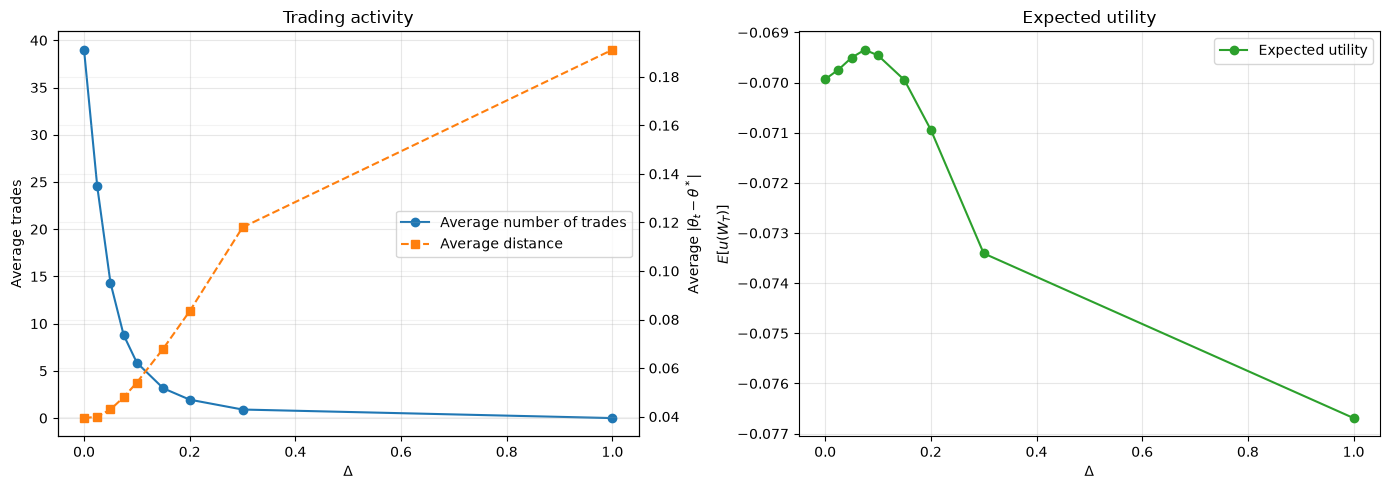

Best Delta: 0.075
Expected utility at best Delta: -0.069347
Improvement relative to Delta=0: 0.000588
Improvement relative to Delta=1: 0.007343
Mean WT is highest at Delta = 1.000.


In [11]:
# 3.3 Simulate all requested no-trade bands with transaction costs
Deltas = [0, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30, 1.0]
results = []
models = {}

for Delta in Deltas:
    model = PortfolioModelClass(Delta=Delta, tau=0.01)
    model.simulate(R_risky)
    models[Delta] = model
    row = model.summary()
    row['Delta'] = Delta
    results.append(row)

results_df = pd.DataFrame(results)[
    ['Delta', 'Avg trades', 'Avg distance', 'Mean WT', 'Median WT', 'P10 WT', 'Expected utility']
]
print(results_df.round(6).to_string(index=False))

# Figure 3: trading activity and expected utility
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
line_trades = ax[0].plot(results_df['Delta'], results_df['Avg trades'], 'o-',
                         label='Average number of trades')
ax[0].set(xlabel=r'$\Delta$', ylabel='Average trades', title='Trading activity')
ax[0].grid(alpha=0.3)
ax_distance = ax[0].twinx()
line_distance = ax_distance.plot(results_df['Delta'], results_df['Avg distance'], 's--',
                                 color='tab:orange', label='Average distance')
ax_distance.set_ylabel(r'Average $|\theta_t-\theta^*|$')
ax[0].legend(line_trades + line_distance,
             [line.get_label() for line in line_trades + line_distance], loc='center right')
ax_distance.grid(alpha=0.15)

ax[1].plot(results_df['Delta'], results_df['Expected utility'], 'o-', color='tab:green',
           label='Expected utility')
ax[1].set(xlabel=r'$\Delta$', ylabel=r'$E[u(W_T)]$', title='Expected utility')
ax[1].legend()
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Best rule and comparisons with the two extremes
best_idx = results_df['Expected utility'].idxmax()
best_delta = results_df.loc[best_idx, 'Delta']
best_utility = results_df.loc[best_idx, 'Expected utility']
utility_delta0 = results_df.loc[results_df['Delta'] == 0, 'Expected utility'].iloc[0]
utility_delta1 = results_df.loc[results_df['Delta'] == 1, 'Expected utility'].iloc[0]

print(f'Best Delta: {best_delta:.3f}')
print(f'Expected utility at best Delta: {best_utility:.6f}')
print(f'Improvement relative to Delta=0: {best_utility - utility_delta0:.6f}')
print(f'Improvement relative to Delta=1: {best_utility - utility_delta1:.6f}')
print(f'Mean WT is highest at Delta = {results_df.loc[results_df["Mean WT"].idxmax(), "Delta"]:.3f}.')